# Student Performance Prediction — EDA & Modeling

**AI (UCS411) Project** — Thapar Institute of Engineering & Technology
Dhruv Kumar (102303376) · Tanvir Kaur (102303389) · Farhan Kazi (102303394)

This notebook predicts a student's final-grade band (**Low / Medium / High**) using the
[UCI Student Performance dataset](https://archive.ics.uci.edu/ml/datasets/Student+Performance)
(Cortez & Silva, 2008).

**What's new vs. the original coursework version:**
- Proper `sklearn` `Pipeline` + `ColumnTransformer` (no manual label-encoding leakage)
- Engineered features (`avg_alcohol`, `parent_edu_avg`, `avg_prior_grade`)
- Stratified 5-fold cross-validation instead of a single train/test split
- Hyperparameter tuning (`GridSearchCV`) for Random Forest and XGBoost
- SHAP explainability for the final model
- An ablation study: how well can we predict performance *without* prior grades (G1/G2)?


In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

from preprocess import load_data, add_features, add_target_class, build_preprocessor, prepare_dataset


## 1. Load & inspect the data

In [2]:
df = load_data("../data/student-mat.csv")
print(df.shape)
df.head()


(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [4]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 2. Exploratory Data Analysis

### 2.1 Distribution of final grades (G3)

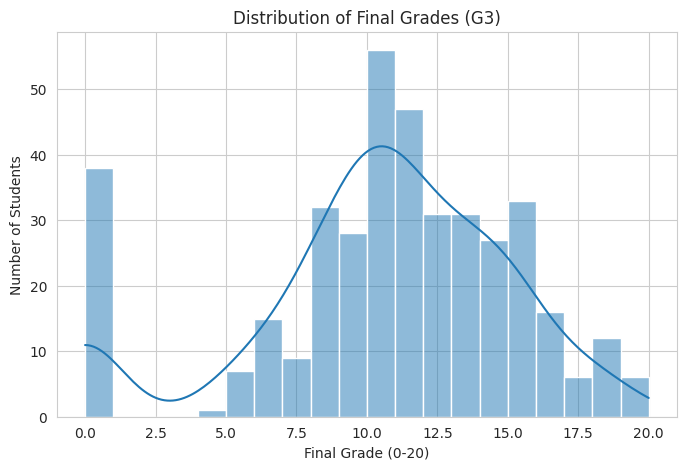

In [5]:
sns.histplot(df["G3"], kde=True, bins=20)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (0-20)")
plt.ylabel("Number of Students")
plt.show()


### 2.2 Study time vs. final grade

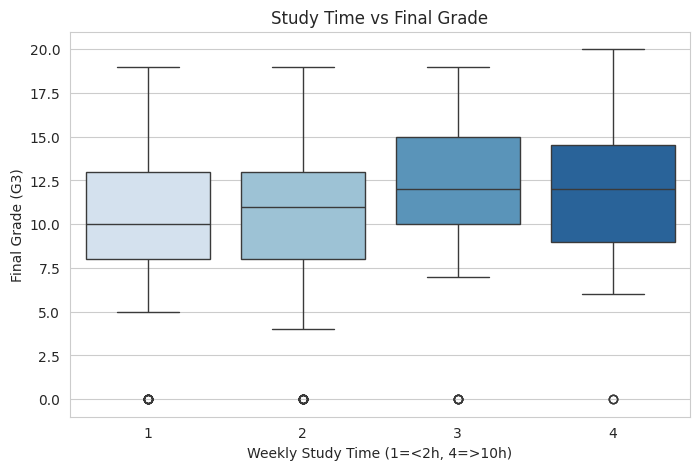

In [6]:
sns.boxplot(x="studytime", y="G3", data=df, palette="Blues")
plt.title("Study Time vs Final Grade")
plt.xlabel("Weekly Study Time (1=<2h, 4=>10h)")
plt.ylabel("Final Grade (G3)")
plt.show()


### 2.3 Absences vs. final grade

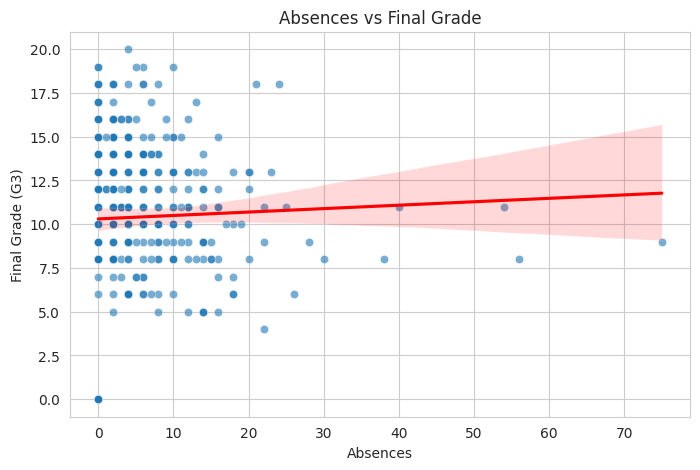

In [7]:
sns.scatterplot(x="absences", y="G3", data=df, alpha=0.6)
sns.regplot(x="absences", y="G3", data=df, scatter=False, color="red")
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")
plt.show()


### 2.4 Correlation heatmap (numeric features)

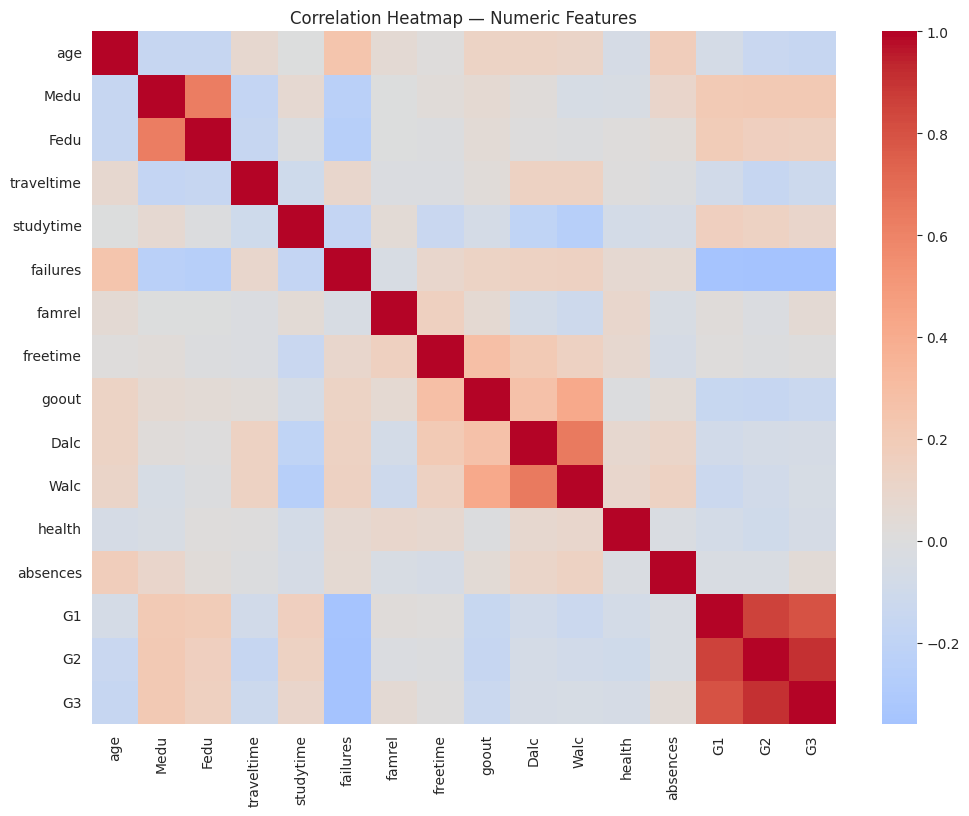

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap — Numeric Features")
plt.show()


### 2.5 Class balance of the target

We bucket the numeric `G3` grade (0-20) into three bands: **Low (0-9), Medium (10-14), High (15-20)**.

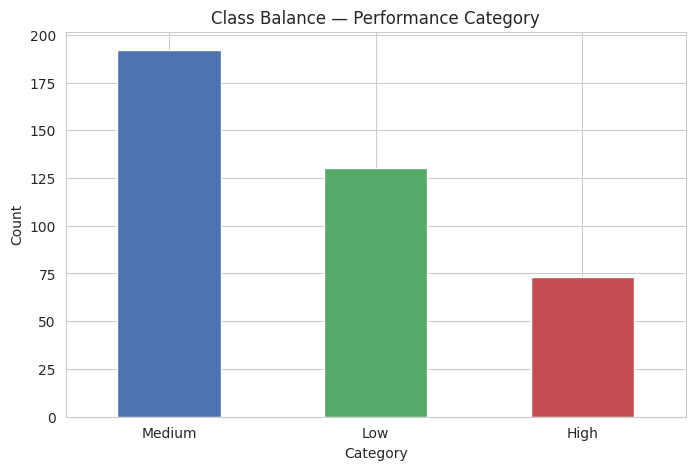

G3_cat
Medium    192
Low       130
High       73
Name: count, dtype: int64

In [9]:
df_labeled = add_target_class(df)
ax = df_labeled["G3_cat"].value_counts().plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Class Balance — Performance Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
df_labeled["G3_cat"].value_counts()


## 3. Feature Engineering

Beyond the raw UCI columns, we add three engineered features that give the models (and the
report's discussion section) more signal and more interpretable structure:

- **`avg_alcohol`** = mean of workday (`Dalc`) and weekend (`Walc`) alcohol consumption
- **`parent_edu_avg`** = mean of mother's and father's education level
- **`avg_prior_grade`** = mean of `G1` and `G2` (captures overall prior trend, not just the two individually)


In [10]:
df_fe = add_features(df_labeled)
df_fe[["Dalc", "Walc", "avg_alcohol", "Medu", "Fedu", "parent_edu_avg", "G1", "G2", "avg_prior_grade"]].head()


,Dalc,Walc,avg_alcohol,Medu,Fedu,parent_edu_avg,G1,G2,avg_prior_grade
0,1,1,1.0,4,4,4.0,5,6,5.5
1,1,1,1.0,1,1,1.0,5,5,5.0
2,2,3,2.5,1,1,1.0,7,8,7.5
3,1,1,1.0,4,2,3.0,15,14,14.5
4,1,2,1.5,3,3,3.0,6,10,8.0


## 4. Preprocessing pipeline

Instead of manually label-encoding every categorical column (which silently imposes a false
ordinal relationship on nominal variables like `Mjob`), we build a `ColumnTransformer` that:

- One-hot encodes **binary** yes/no style columns
- One-hot encodes **nominal** multi-category columns (`Mjob`, `Fjob`, `reason`, `guardian`)
- Standard-scales **numeric** columns

This is wrapped in a single `sklearn.Pipeline` together with the classifier, so preprocessing
is always fit *only* on the training fold — no data leakage across CV folds.


In [11]:
from sklearn.model_selection import train_test_split

X, y, target_encoder = prepare_dataset("../data/student-mat.csv")
print("Features:", X.shape, " Target classes:", list(target_encoder.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
preprocessor = build_preprocessor()


Features: (395, 35)  Target classes: ['High', 'Low', 'Medium']


## 5. Model comparison (5-fold stratified cross-validation)

Rather than judging models on a single 80/20 split (noisy with only ~395 rows), we use
5-fold stratified CV and report mean accuracy and macro-F1 (macro-F1 matters more here since
the "Low" class is a minority class).


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "k-NN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0),
}

rows = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    rows.append({"Model": name, "CV Accuracy": acc.mean(), "CV Macro F1": f1.mean()})
    print(f"{name:22s} | Acc: {acc.mean():.3f} ± {acc.std():.3f} | F1(macro): {f1.mean():.3f} ± {f1.std():.3f}")

results_df = pd.DataFrame(rows).sort_values("CV Macro F1", ascending=False)
results_df


Logistic Regression    | Acc: 0.835 ± 0.019 | F1(macro): 0.833 ± 0.020


Decision Tree          | Acc: 0.842 ± 0.022 | F1(macro): 0.844 ± 0.025


Random Forest          | Acc: 0.867 ± 0.045 | F1(macro): 0.869 ± 0.042


k-NN                   | Acc: 0.706 ± 0.050 | F1(macro): 0.696 ± 0.056


XGBoost                | Acc: 0.886 ± 0.043 | F1(macro): 0.891 ± 0.038


,Model,CV Accuracy,CV Macro F1
4,XGBoost,0.886062,0.891497
2,Random Forest,0.867014,0.868632
1,Decision Tree,0.841815,0.844075
0,Logistic Regression,0.835466,0.833489
3,k-NN,0.705655,0.695602


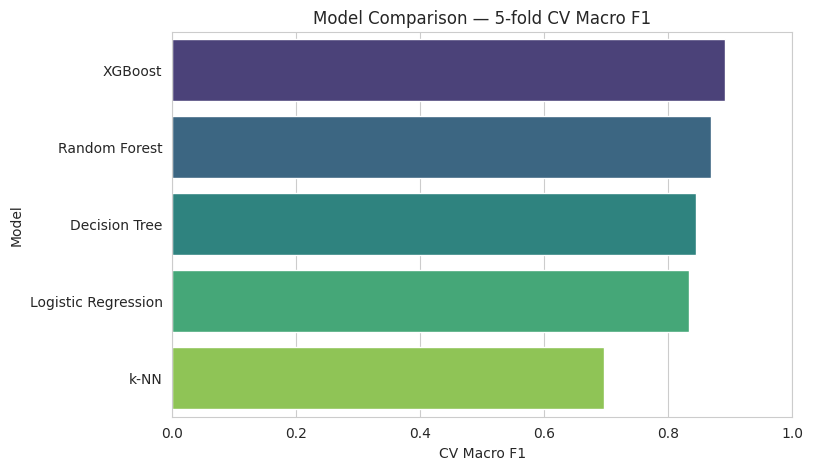

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="CV Macro F1", y="Model", palette="viridis")
plt.title("Model Comparison — 5-fold CV Macro F1")
plt.xlim(0, 1)
plt.show()


## 6. Hyperparameter tuning

The two strongest baseline models — Random Forest and XGBoost — are tuned with `GridSearchCV`
(scored on macro-F1, same 5-fold CV) to see how much headroom is left over the defaults.

In [14]:
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(random_state=42))])
rf_grid = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 6, 10, 16],
    "clf__min_samples_split": [2, 4, 8],
    "clf__min_samples_leaf": [1, 2, 4],
}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV Macro F1:", round(rf_search.best_score_, 4))


Best RF params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 4, 'clf__n_estimators': 100}
Best RF CV Macro F1: 0.8914


In [15]:
xgb_pipe = Pipeline([("prep", preprocessor), ("clf", XGBClassifier(
    eval_metric="mlogloss", random_state=42, verbosity=0
))])
xgb_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 4, 6],
    "clf__learning_rate": [0.05, 0.1, 0.2],
}
xgb_search = GridSearchCV(xgb_pipe, xgb_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB CV Macro F1:", round(xgb_search.best_score_, 4))


Best XGB params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__n_estimators': 300}
Best XGB CV Macro F1: 0.8991


## 7. Final model selection & held-out test evaluation

In [16]:
candidates = {
    "Random Forest (tuned)": rf_search.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
}
best_name, best_pipeline, best_score = None, None, -1
for name, pipe in candidates.items():
    score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro").mean()
    print(f"{name}: CV Macro F1 = {score:.4f}")
    if score > best_score:
        best_name, best_pipeline, best_score = name, pipe, score

print(f"\nSelected: {best_name}")
best_pipeline.fit(X_train, y_train)


Random Forest (tuned): CV Macro F1 = 0.8914


XGBoost (tuned): CV Macro F1 = 0.8991

Selected: XGBoost (tuned)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bin', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

Test Accuracy: 0.8734
Test Macro F1: 0.8876

              precision    recall  f1-score   support

        High       0.94      1.00      0.97        15
         Low       0.81      0.85      0.83        26
      Medium       0.89      0.84      0.86        38

    accuracy                           0.87        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.87      0.87      0.87        79



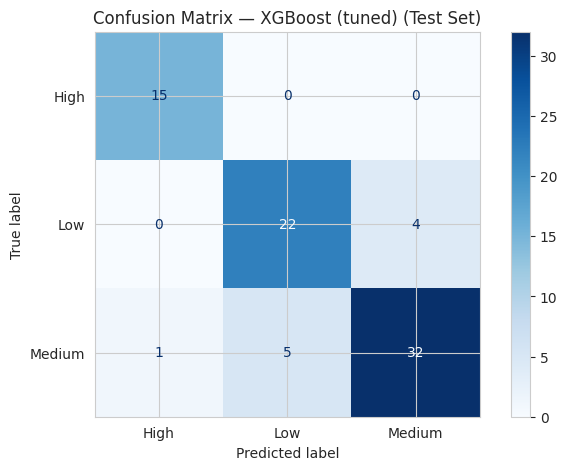

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

y_pred = best_pipeline.predict(X_test)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test Macro F1:", round(f1_score(y_test, y_pred, average="macro"), 4))
print()
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=target_encoder.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix — {best_name} (Test Set)")
plt.show()


## 8. Ablation study: predicting performance *without* prior grades

G1 and G2 dominate the feature importance in almost every student-performance paper — including
this one. That's expected, but also less useful in practice: if you already have a student's
period grades, you don't need a model to tell you they're doing well. The more actionable
question is whether we can flag at-risk students **before** those grades exist, using only
demographic/behavioral data.


In [18]:
X_noprior, y_noprior, _ = prepare_dataset("../data/student-mat.csv", drop_prior_grades=True)
Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X_noprior, y_noprior, test_size=0.2, stratify=y_noprior, random_state=42
)
prep_noprior = build_preprocessor(drop_prior_grades=True)
pipe_noprior = Pipeline([("prep", prep_noprior), ("clf", RandomForestClassifier(n_estimators=300, random_state=42))])
pipe_noprior.fit(Xtr2, ytr2)

acc_noprior = accuracy_score(yte2, pipe_noprior.predict(Xte2))
f1_noprior = f1_score(yte2, pipe_noprior.predict(Xte2), average="macro")
print(f"Without G1/G2 -> Test Accuracy: {acc_noprior:.4f}, Macro F1: {f1_noprior:.4f}")
print(f"With G1/G2    -> Test Accuracy: {accuracy_score(y_test, y_pred):.4f}, Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")


Without G1/G2 -> Test Accuracy: 0.5570, Macro F1: 0.4726
With G1/G2    -> Test Accuracy: 0.8734, Macro F1: 0.8876


**Takeaway:** accuracy drops substantially without prior grades — as expected — but the
model still performs meaningfully above the majority-class baseline using only demographic,
behavioral and lifestyle features. This supports using such a model for *early-semester*
risk flagging, before G1/G2 exist, while the full model (with G1/G2) is better suited for
*mid-year* intervention targeting.

## 9. Feature importance & SHAP explainability

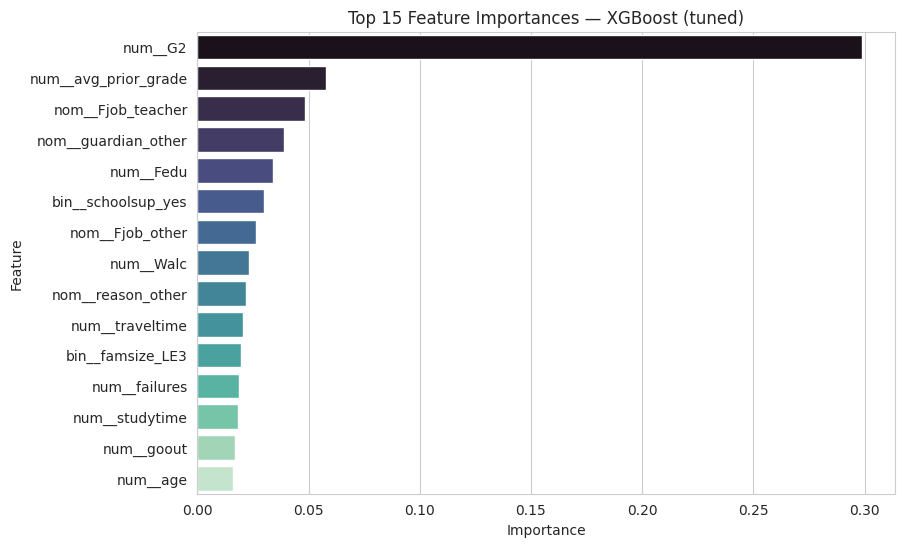

In [19]:
importances = best_pipeline.named_steps["clf"].feature_importances_
feature_names = best_pipeline.named_steps["prep"].get_feature_names_out()

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(
    "Importance", ascending=False
).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="mako")
plt.title(f"Top 15 Feature Importances — {best_name}")
plt.show()


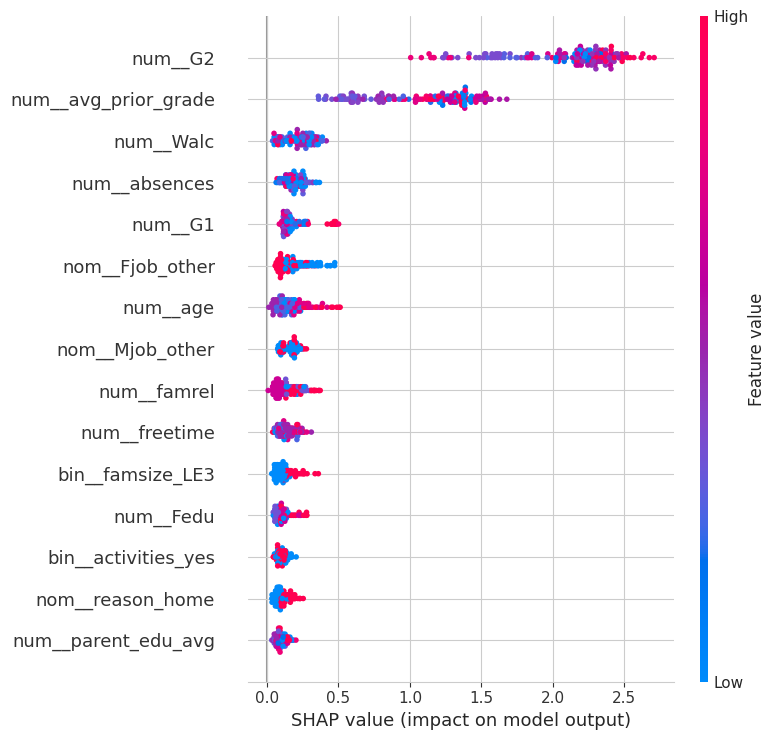

In [20]:
import shap

clf = best_pipeline.named_steps["clf"]
prep = best_pipeline.named_steps["prep"]
X_train_t = prep.transform(X_train)
if hasattr(X_train_t, "toarray"):
    X_train_t = X_train_t.toarray()
sample = X_train_t[:150]

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(sample)
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    shap_values = np.mean(np.abs(shap_values), axis=-1)

shap.summary_plot(shap_values, sample, feature_names=list(feature_names), max_display=15)


**Reading this plot:** `G2` and `avg_prior_grade` dominate, confirming the correlation
heatmap earlier. Beyond grades, weekend alcohol use (`Walc`), absences, and age carry real
signal — consistent with the literature review's finding that behavioral factors matter
alongside academic history.

## 10. Save the final model

In [21]:
import joblib
import json
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/best_model.pkl")
joblib.dump(target_encoder, "../models/target_encoder.pkl")
print("Saved best_model.pkl and target_encoder.pkl to ../models/")


Saved best_model.pkl and target_encoder.pkl to ../models/


## 11. Try it out

Predict a single student's performance category using the saved pipeline (same function
used by `src/predict.py` and the Streamlit app in `app.py`).

In [22]:
import sys
sys.path.insert(0, "../src")
from predict import predict_student, DEFAULT_SAMPLE

result = predict_student(DEFAULT_SAMPLE)
print("Predicted category:", result["prediction"])
print("Probabilities:", result["probabilities"])


Predicted category: High
Probabilities: {'High': 0.9881, 'Low': 0.0001, 'Medium': 0.0118}


## 12. Conclusion

- **XGBoost (tuned)** was the best-performing model on 5-fold CV macro-F1, ahead of Random Forest,
  Decision Tree, Logistic Regression, and k-NN.
- Prior grades (**G2**, then **G1**) remain the dominant predictors, but a meaningful signal
  persists even without them, supporting early-warning use cases.
- Behavioral factors — **absences**, **weekend alcohol use**, **study time** — contribute
  secondary but non-trivial predictive value, matching the discussion in the accompanying report.
- Next steps: try the live Streamlit demo (`app.py`), or read the full write-up in `report/report.pdf`.
